# Combine Existing Plots into Panel Figures

This notebook loads already-saved PNG plot images from the results folder and combines them into comprehensive panel figures for easier comparison across noise levels (tau values).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.gridspec import GridSpec
from pathlib import Path
import re
from typing import List, Dict, Optional, Tuple
import os
import numpy as np
from PIL import Image
import gc

# Setup paths
project_root = Path.cwd().parent if Path.cwd().name == 'Experiments' else Path.cwd()
results_dir = project_root / "results" / "noise_level"
plots_dir = results_dir / "plots"
panels_dir = results_dir / "panels"
panels_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Plots directory: {plots_dir}")
print(f"Output panels directory: {panels_dir}")

Project root: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1
Plots directory: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\plots
Output panels directory: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels


In [2]:
# Define plot locations
VARIANCE_DIR = plots_dir / "uncertainties"
ENTROPY_DIR = plots_dir / "uncertainties_entropy_no_ood_normalized"

# Model name patterns in filenames
MODEL_PATTERNS = {
    'MC_Dropout': 'MC_Dropout_(β-NLL,_β=0.5)',
    'Deep_Ensemble': 'Deep_Ensemble_(β-NLL,_β=0.5)',
    'BAMLSS': 'BAMLSS',
    'BNN': 'BNN_(Pyro_NUTS)'
}

# Function types
FUNC_TYPES = {
    'sin': 'Sinusoidal',
    'linear': 'Linear'
}

# Noise types
NOISE_TYPES = ['heteroscedastic', 'homoscedastic']

# Tau values
TAU_VALUES = [0.5, 1.0, 2.0, 2.5, 5.0]

print("Configuration loaded.")

Configuration loaded.


In [ ]:
# Image loading with memory-efficient resizing
MAX_IMAGE_SIZE = (800, 600)  # Maximum dimensions for loaded images

def load_image_resized(path: Path, max_size: Tuple[int, int] = MAX_IMAGE_SIZE) -> np.ndarray:
    """
    Load an image and resize it to fit within max_size while preserving aspect ratio.
    This prevents memory issues when combining many large images.
    
    Parameters:
    -----------
    path : Path
        Path to the image file
    max_size : tuple
        Maximum (width, height) for the loaded image
    
    Returns:
    --------
    img : np.ndarray
        Image as numpy array (normalized to 0-1 for display)
    """
    with Image.open(str(path)) as pil_img:
        # Convert to RGB if necessary (handles RGBA, grayscale, etc.)
        if pil_img.mode != 'RGB':
            pil_img = pil_img.convert('RGB')
        
        # Resize while preserving aspect ratio
        pil_img.thumbnail(max_size, Image.Resampling.LANCZOS)
        
        # Convert to numpy array and normalize to 0-1
        img = np.array(pil_img, dtype=np.float32) / 255.0
        
    return img


def clear_memory():
    """Clear matplotlib figures and run garbage collection."""
    plt.close('all')
    gc.collect()


print(f"Image loading configured with max size: {MAX_IMAGE_SIZE}")
print("Memory-efficient loading enabled.")

In [3]:
def get_variance_plot_path(
    model_key: str,
    func_type: str,
    noise_type: str,
    tau: float,
    distribution: str = 'normal'
) -> Path:
    """
    Construct the path to a variance plot.
    
    Example: MC_Dropout_(β-NLL,_β=0.5)_-_Sinusoidal_-_τ=0.5_(normal)_-_Variance.png
    """
    model_name = MODEL_PATTERNS[model_key]
    func_name = FUNC_TYPES[func_type]
    
    # Handle tau formatting (remove trailing .0 for whole numbers)
    tau_str = str(int(tau)) if tau == int(tau) else str(tau)
    
    filename = f"{model_name}_-_{func_name}_-_τ={tau_str}_({distribution})_-_Variance.png"
    return VARIANCE_DIR / noise_type / func_type / filename


def get_entropy_plot_path(
    model_key: str,
    func_type: str,
    noise_type: str,
    tau: float,
    distribution: str = 'normal'
) -> Path:
    """
    Construct the path to an entropy plot.
    
    Example: MC_Dropout_(β-NLL,_β=0.5)_-_Sinusoidal_-_τ=0.5_(normal)_-_Entropy_entropy_normalized.png
    """
    model_name = MODEL_PATTERNS[model_key]
    func_name = FUNC_TYPES[func_type]
    
    tau_str = str(int(tau)) if tau == int(tau) else str(tau)
    
    filename = f"{model_name}_-_{func_name}_-_τ={tau_str}_({distribution})_-_Entropy_entropy_normalized.png"
    return ENTROPY_DIR / noise_type / func_type / filename


def check_available_plots(model_key: str, func_type: str, noise_type: str) -> Dict[str, List[float]]:
    """
    Check which tau values have available plots for a given model/func/noise combination.
    """
    available = {'variance': [], 'entropy': []}
    
    for tau in TAU_VALUES:
        var_path = get_variance_plot_path(model_key, func_type, noise_type, tau)
        if var_path.exists():
            available['variance'].append(tau)
        
        ent_path = get_entropy_plot_path(model_key, func_type, noise_type, tau)
        if ent_path.exists():
            available['entropy'].append(tau)
    
    return available


# Test path construction
test_path = get_variance_plot_path('MC_Dropout', 'sin', 'heteroscedastic', 0.5)
print(f"Test path: {test_path}")
print(f"Exists: {test_path.exists()}")

Test path: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\plots\uncertainties\heteroscedastic\sin\MC_Dropout_(β-NLL,_β=0.5)_-_Sinusoidal_-_τ=0.5_(normal)_-_Variance.png
Exists: True


In [4]:
def create_model_panel(
    model_key: str,
    func_type: str,
    noise_type: str,
    tau_values: List[float] = None,
    include_entropy: bool = True,
    figsize_per_image: Tuple[float, float] = (4, 3),
    dpi: int = 150
) -> Optional[plt.Figure]:
    """
    Create a panel figure combining all tau values for a single model.
    
    Layout:
    - If include_entropy=True: 2 rows (variance, entropy) x n_tau columns
    - If include_entropy=False: 1 row x n_tau columns
    
    Parameters:
    -----------
    model_key : str
        Key from MODEL_PATTERNS ('MC_Dropout', 'Deep_Ensemble', 'BAMLSS', 'BNN')
    func_type : str
        'sin' or 'linear'
    noise_type : str
        'heteroscedastic' or 'homoscedastic'
    tau_values : list, optional
        List of tau values to include. If None, uses all available.
    include_entropy : bool
        Whether to include entropy row
    figsize_per_image : tuple
        Size of each subplot
    dpi : int
        Resolution for saving
    
    Returns:
    --------
    fig : matplotlib.figure.Figure or None if no plots found
    """
    if tau_values is None:
        tau_values = TAU_VALUES
    
    # Collect available images
    variance_images = []
    entropy_images = []
    valid_taus = []
    
    for tau in tau_values:
        var_path = get_variance_plot_path(model_key, func_type, noise_type, tau)
        ent_path = get_entropy_plot_path(model_key, func_type, noise_type, tau)
        
        if var_path.exists():
            variance_images.append((tau, var_path))
            valid_taus.append(tau)
            
            if include_entropy and ent_path.exists():
                entropy_images.append((tau, ent_path))
    
    if not variance_images:
        print(f"No variance plots found for {model_key}, {func_type}, {noise_type}")
        return None
    
    n_cols = len(variance_images)
    n_rows = 2 if (include_entropy and entropy_images) else 1
    
    # Create figure
    fig_width = figsize_per_image[0] * n_cols
    fig_height = figsize_per_image[1] * n_rows + 0.8  # Extra space for title
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    
    # Handle single row case
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Plot variance row
    for col_idx, (tau, path) in enumerate(variance_images):
        img = load_image_resized(path)
        axes[0, col_idx].imshow(img)
        axes[0, col_idx].axis('off')
        axes[0, col_idx].set_title(f'τ = {tau}', fontsize=10, fontweight='bold')
        del img  # Free memory immediately
    
    # Add row label for variance
    axes[0, 0].text(-0.05, 0.5, 'Variance', transform=axes[0, 0].transAxes,
                    fontsize=11, fontweight='bold', rotation=90,
                    ha='right', va='center')
    
    # Plot entropy row if available
    if n_rows == 2 and entropy_images:
        # Create mapping from tau to entropy path
        entropy_dict = {tau: path for tau, path in entropy_images}
        
        for col_idx, (tau, _) in enumerate(variance_images):
            if tau in entropy_dict:
                img = load_image_resized(entropy_dict[tau])
                axes[1, col_idx].imshow(img)
                del img  # Free memory immediately
            axes[1, col_idx].axis('off')
        
        # Add row label for entropy
        axes[1, 0].text(-0.05, 0.5, 'Entropy', transform=axes[1, 0].transAxes,
                        fontsize=11, fontweight='bold', rotation=90,
                        ha='right', va='center')
    
    # Main title
    model_display = model_key.replace('_', ' ')
    func_display = FUNC_TYPES[func_type]
    title = f"{model_display} - {func_display} Function ({noise_type})"
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0.02, 0, 1, 0.95])
    
    return fig


print("Panel creation function defined.")

Panel creation function defined.


In [5]:
def create_all_models_panel(
    func_type: str,
    noise_type: str,
    tau_values: List[float] = None,
    plot_type: str = 'variance',  # 'variance' or 'entropy'
    figsize_per_image: Tuple[float, float] = (3.5, 2.5),
) -> Optional[plt.Figure]:
    """
    Create a panel showing all models across all tau values.
    
    Layout: 4 rows (one per model) x n_tau columns
    
    Parameters:
    -----------
    func_type : str
        'sin' or 'linear'
    noise_type : str
        'heteroscedastic' or 'homoscedastic'
    tau_values : list, optional
        List of tau values to include
    plot_type : str
        'variance' or 'entropy'
    
    Returns:
    --------
    fig : matplotlib.figure.Figure or None
    """
    if tau_values is None:
        tau_values = TAU_VALUES
    
    model_keys = list(MODEL_PATTERNS.keys())
    n_rows = len(model_keys)
    n_cols = len(tau_values)
    
    # Get path function based on plot type
    get_path = get_variance_plot_path if plot_type == 'variance' else get_entropy_plot_path
    
    # Create figure
    fig_width = figsize_per_image[0] * n_cols
    fig_height = figsize_per_image[1] * n_rows + 1.0
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
    
    for row_idx, model_key in enumerate(model_keys):
        for col_idx, tau in enumerate(tau_values):
            path = get_path(model_key, func_type, noise_type, tau)
            
            if path.exists():
                img = load_image_resized(path)
                axes[row_idx, col_idx].imshow(img)
                del img  # Free memory immediately
            else:
                axes[row_idx, col_idx].text(0.5, 0.5, 'Not\nAvailable',
                                            ha='center', va='center',
                                            fontsize=10, color='gray')
            
            axes[row_idx, col_idx].axis('off')
            
            # Column titles (tau values) - only on first row
            if row_idx == 0:
                axes[row_idx, col_idx].set_title(f'τ = {tau}', fontsize=10, fontweight='bold')
        
        # Row labels (model names)
        model_display = model_key.replace('_', ' ')
        axes[row_idx, 0].text(-0.05, 0.5, model_display,
                              transform=axes[row_idx, 0].transAxes,
                              fontsize=10, fontweight='bold', rotation=90,
                              ha='right', va='center')
    
    # Main title
    func_display = FUNC_TYPES[func_type]
    type_display = 'Variance' if plot_type == 'variance' else 'Entropy'
    title = f"All Models - {func_display} ({noise_type}) - {type_display} Decomposition"
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.99)
    
    plt.tight_layout(rect=[0.03, 0, 1, 0.96])
    
    return fig


print("All-models panel function defined.")

All-models panel function defined.


In [6]:
# Check what plots are available
print("Checking available plots...\n")

for noise_type in NOISE_TYPES:
    for func_type in ['sin', 'linear']:
        print(f"\n{'='*60}")
        print(f"{noise_type.upper()} - {func_type.upper()}")
        print('='*60)
        
        for model_key in MODEL_PATTERNS.keys():
            available = check_available_plots(model_key, func_type, noise_type)
            print(f"\n{model_key}:")
            print(f"  Variance: τ = {available['variance']}")
            print(f"  Entropy:  τ = {available['entropy']}")

Checking available plots...


HETEROSCEDASTIC - SIN

MC_Dropout:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

Deep_Ensemble:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

BAMLSS:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

BNN:
  Variance: τ = [0.5, 5.0]
  Entropy:  τ = [0.5, 5.0]

HETEROSCEDASTIC - LINEAR

MC_Dropout:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

Deep_Ensemble:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

BAMLSS:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

BNN:
  Variance: τ = [0.5, 5.0]
  Entropy:  τ = [0.5, 5.0]

HOMOSCEDASTIC - SIN

MC_Dropout:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

Deep_Ensemble:
  Variance: τ = [0.5, 1.0, 2.0, 2.5, 5.0]
  Entropy:  τ = [0.5, 1.0, 2.0, 2.5, 5.0]

BAM

## MC Dropout Panels

Saved: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels\MC_Dropout_sin_heteroscedastic_panel.png


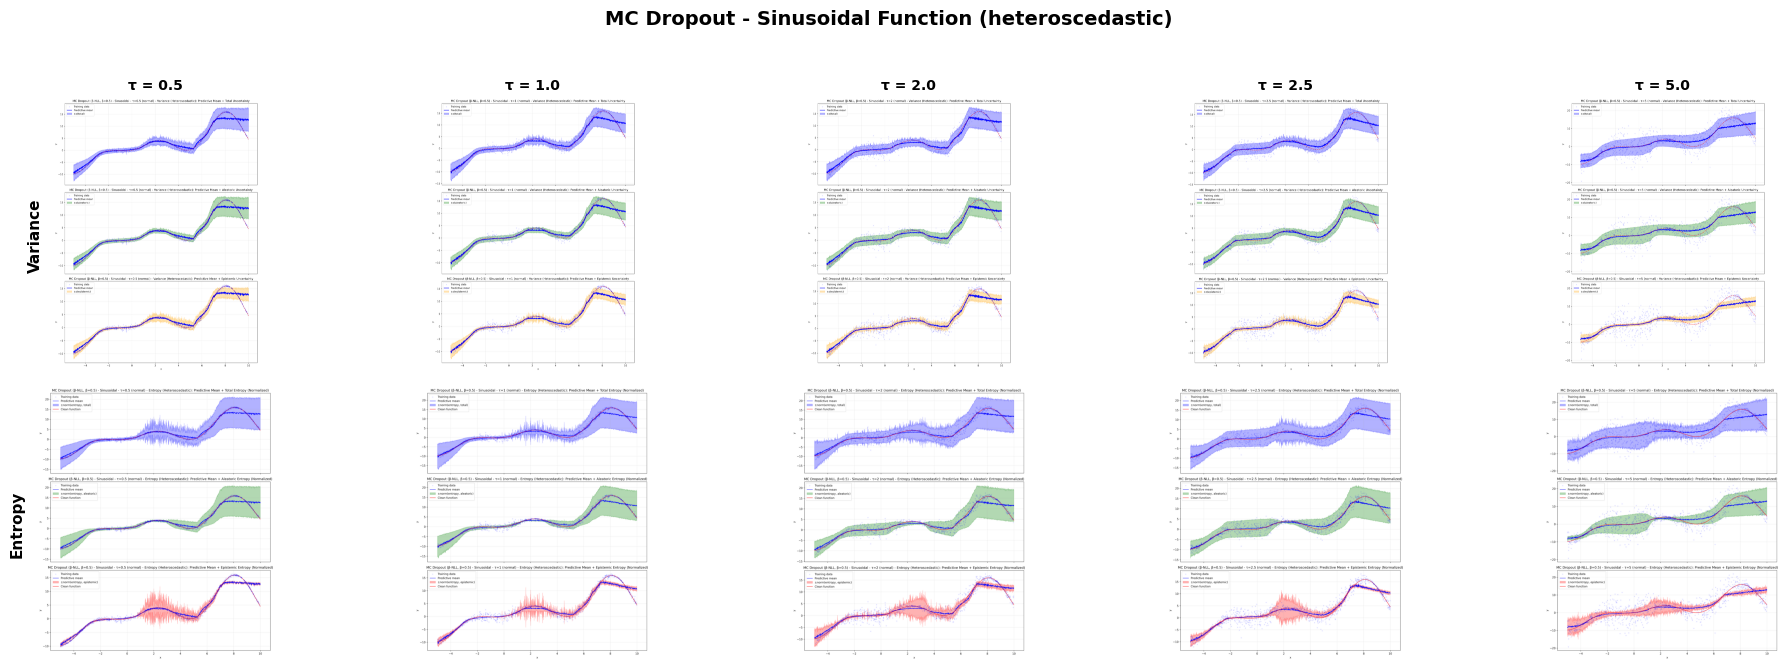

In [7]:
# MC Dropout - Heteroscedastic Sinusoidal
fig = create_model_panel('MC_Dropout', 'sin', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'MC_Dropout_sin_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()  # Free memory after display
else:
    print("No plots available for this combination.")

Saved: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels\MC_Dropout_linear_heteroscedastic_panel.png


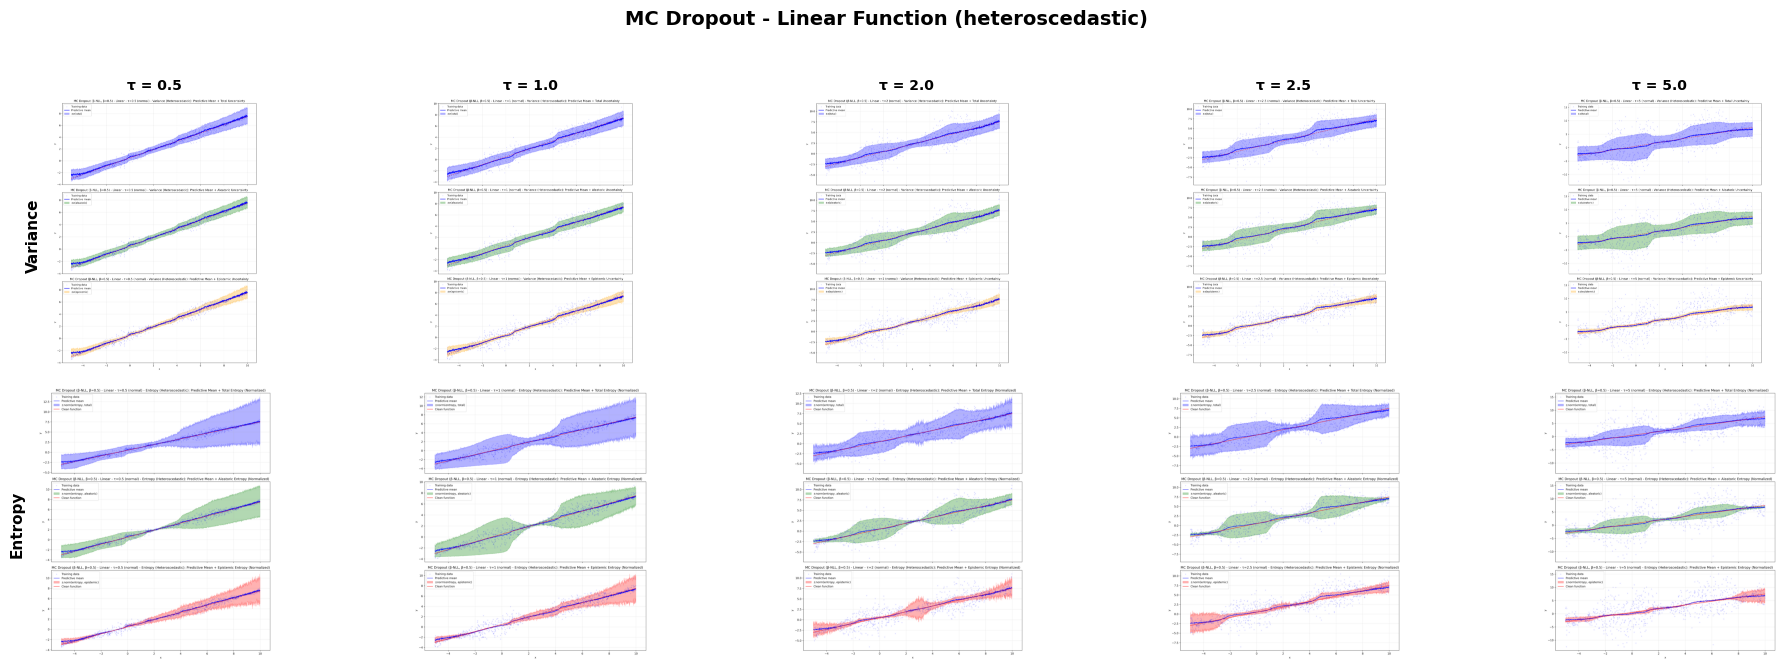

In [8]:
# MC Dropout - Heteroscedastic Linear
fig = create_model_panel('MC_Dropout', 'linear', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'MC_Dropout_linear_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

Saved: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels\MC_Dropout_sin_homoscedastic_panel.png


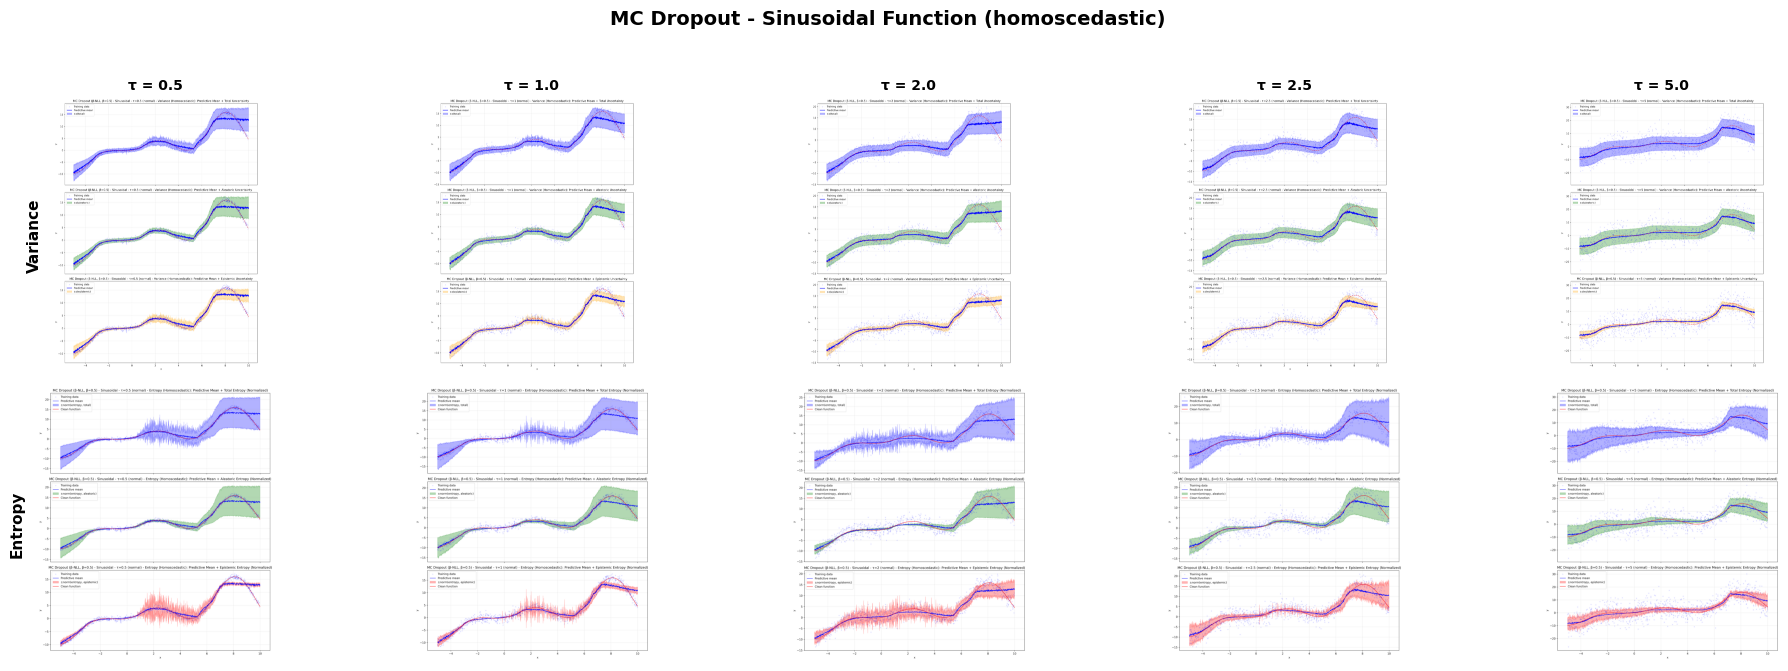

In [9]:
# MC Dropout - Homoscedastic Sinusoidal
fig = create_model_panel('MC_Dropout', 'sin', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'MC_Dropout_sin_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

Saved: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels\MC_Dropout_linear_homoscedastic_panel.png


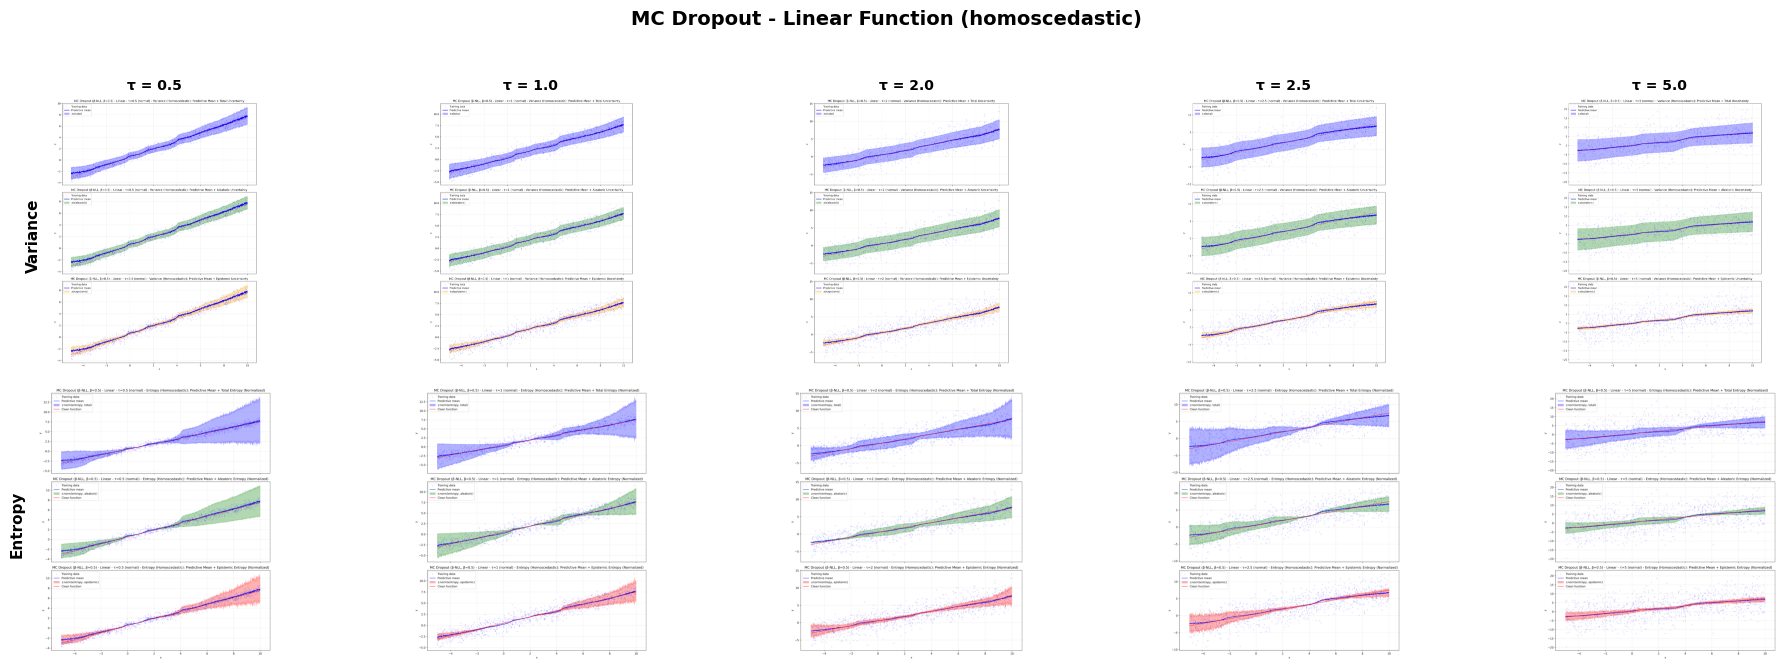

In [10]:
# MC Dropout - Homoscedastic Linear
fig = create_model_panel('MC_Dropout', 'linear', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'MC_Dropout_linear_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

## Deep Ensemble Panels

Saved: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels\Deep_Ensemble_sin_heteroscedastic_panel.png


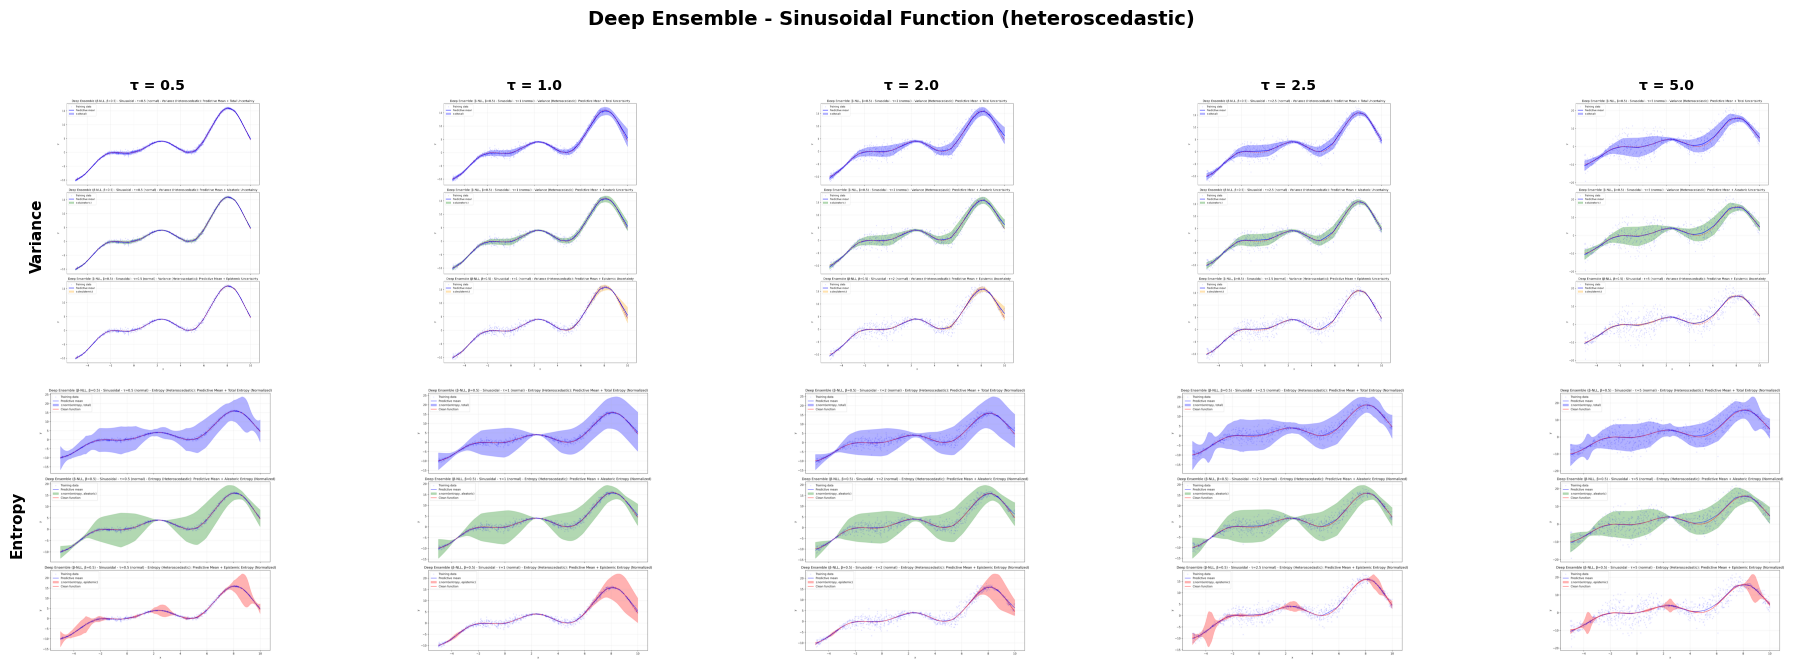

In [11]:
# Deep Ensemble - Heteroscedastic Sinusoidal
fig = create_model_panel('Deep_Ensemble', 'sin', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'Deep_Ensemble_sin_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

Saved: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\noise_level\panels\Deep_Ensemble_linear_heteroscedastic_panel.png


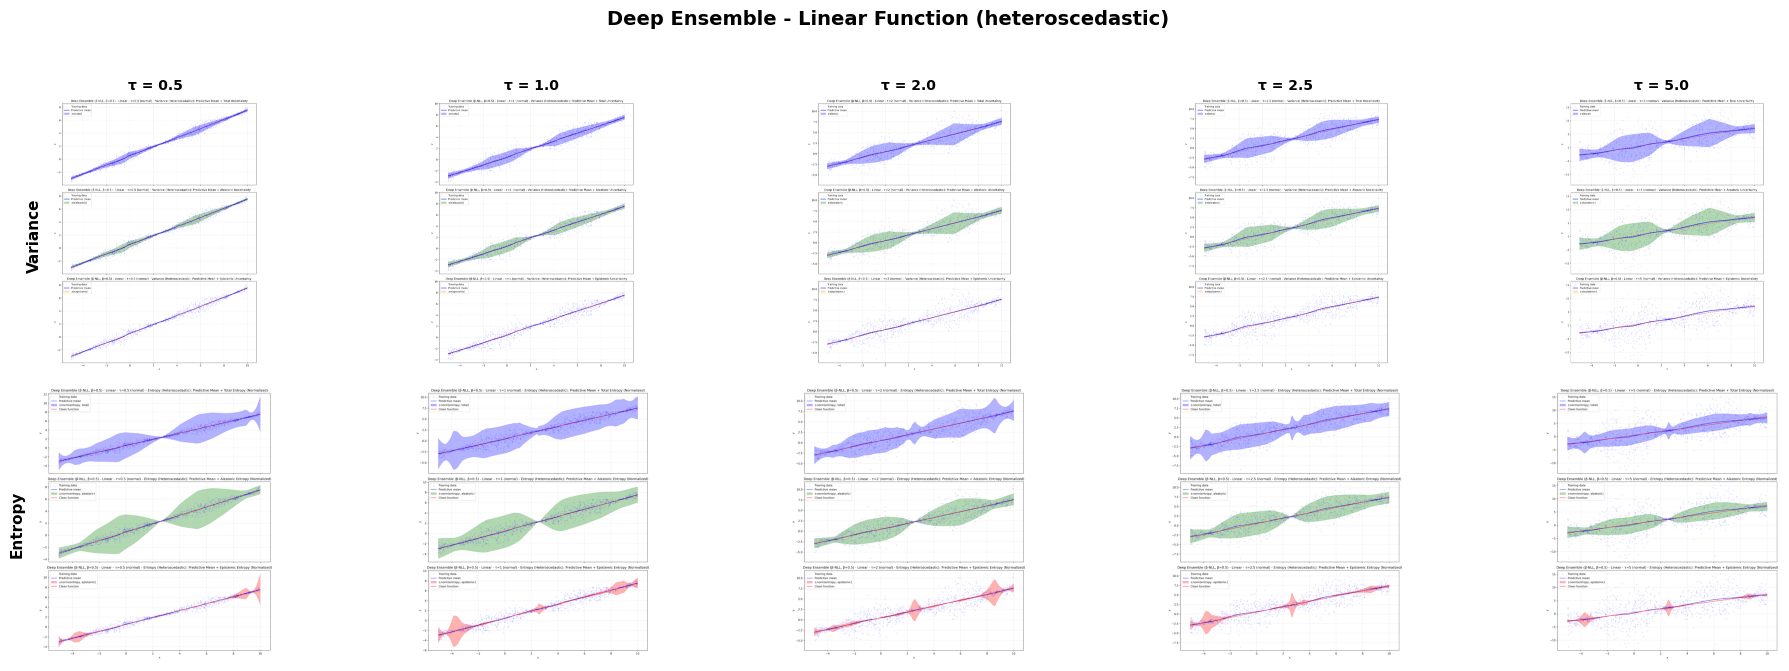

In [12]:
# Deep Ensemble - Heteroscedastic Linear
fig = create_model_panel('Deep_Ensemble', 'linear', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'Deep_Ensemble_linear_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# Deep Ensemble - Homoscedastic Sinusoidal
fig = create_model_panel('Deep_Ensemble', 'sin', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'Deep_Ensemble_sin_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

MemoryError: 

Error in callback <function _draw_all_if_interactive at 0x000001CB4EC9CE00> (for post_execute), with arguments args (),kwargs {}:


In [ ]:
# Deep Ensemble - Homoscedastic Linear
fig = create_model_panel('Deep_Ensemble', 'linear', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'Deep_Ensemble_linear_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

## BAMLSS Panels

In [ ]:
# BAMLSS - Heteroscedastic Sinusoidal
fig = create_model_panel('BAMLSS', 'sin', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BAMLSS_sin_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# BAMLSS - Heteroscedastic Linear
fig = create_model_panel('BAMLSS', 'linear', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BAMLSS_linear_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

In [ ]:
# BAMLSS - Homoscedastic Sinusoidal
fig = create_model_panel('BAMLSS', 'sin', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BAMLSS_sin_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# BAMLSS - Homoscedastic Linear
fig = create_model_panel('BAMLSS', 'linear', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BAMLSS_linear_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

## BNN Panels

In [ ]:
# BNN - Heteroscedastic Sinusoidal
fig = create_model_panel('BNN', 'sin', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BNN_sin_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

In [ ]:
# BNN - Heteroscedastic Linear
fig = create_model_panel('BNN', 'linear', 'heteroscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BNN_linear_heteroscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# BNN - Homoscedastic Sinusoidal
fig = create_model_panel('BNN', 'sin', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BNN_sin_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

In [ ]:
# BNN - Homoscedastic Linear
fig = create_model_panel('BNN', 'linear', 'homoscedastic', include_entropy=True)

if fig:
    save_path = panels_dir / 'BNN_linear_homoscedastic_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

## All Models Comparison Panels

These panels show all 4 models side by side across all tau values.

In [ ]:
# All Models - Heteroscedastic Sinusoidal - Variance
fig = create_all_models_panel('sin', 'heteroscedastic', plot_type='variance')

if fig:
    save_path = panels_dir / 'All_Models_sin_heteroscedastic_variance_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# All Models - Heteroscedastic Sinusoidal - Entropy
fig = create_all_models_panel('sin', 'heteroscedastic', plot_type='entropy')

if fig:
    save_path = panels_dir / 'All_Models_sin_heteroscedastic_entropy_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

In [ ]:
# All Models - Heteroscedastic Linear - Variance
fig = create_all_models_panel('linear', 'heteroscedastic', plot_type='variance')

if fig:
    save_path = panels_dir / 'All_Models_linear_heteroscedastic_variance_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# All Models - Heteroscedastic Linear - Entropy
fig = create_all_models_panel('linear', 'heteroscedastic', plot_type='entropy')

if fig:
    save_path = panels_dir / 'All_Models_linear_heteroscedastic_entropy_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# All Models - Homoscedastic Sinusoidal - Variance
fig = create_all_models_panel('sin', 'homoscedastic', plot_type='variance')

if fig:
    save_path = panels_dir / 'All_Models_sin_homoscedastic_variance_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# All Models - Homoscedastic Sinusoidal - Entropy
fig = create_all_models_panel('sin', 'homoscedastic', plot_type='entropy')

if fig:
    save_path = panels_dir / 'All_Models_sin_homoscedastic_entropy_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

In [ ]:
# All Models - Homoscedastic Linear - Variance
fig = create_all_models_panel('linear', 'homoscedastic', plot_type='variance')

if fig:
    save_path = panels_dir / 'All_Models_linear_homoscedastic_variance_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()

In [ ]:
# All Models - Homoscedastic Linear - Entropy
fig = create_all_models_panel('linear', 'homoscedastic', plot_type='entropy')

if fig:
    save_path = panels_dir / 'All_Models_linear_homoscedastic_entropy_panel.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Saved: {save_path}")
    plt.show()
    clear_memory()

## Summary

In [ ]:
# Summary of all saved panel plots
print("\n" + "="*80)
print("SUMMARY OF SAVED PANEL PLOTS")
print("="*80)

saved_panels = sorted(panels_dir.glob('*.png'))
for f in saved_panels:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")

print(f"\nTotal panels saved: {len(saved_panels)}")
print(f"Location: {panels_dir}")